In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load datasets
train = pd.read_csv("public_trip_data.csv")
test = pd.read_csv("private_trip_data.csv")

In [4]:
train.head()

,TripID,DepartureLocationCountry,DepartureLocationCity,ArrivalLocationCountry,ArrivalLocationCity,ShippingType,ShippingTypeDescription,Purpose,OutOfPolicy,EntitiyCode,EmployeeNumber,BusinessUnit,HotelNights,NetCosts,Departure_CO2e,Return_CO2e,Hotel_CO2e,Spend_CO2e,TotalCO2e,HighCarbon
0,1,CN,Beijing,IN,New Delhi,12,Business Class Flight,Customer Visit,No,9000,M1000-M5008,Services,1,900,1565.121857,1565.121857,58.9,1472.279257,3189.143714,0
1,3,US,New York,MX,Mexico City,11,First Class Flight,Customer Visit,Yes,6000,M1000-M5030,Sales,2,3600,743.295848,743.295848,38.6,2921.504761,1525.191696,0
2,6,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Conference/Exhibition,No,9000,M1000-M5069,Services,1,450,1053.713528,1053.713528,51.4,743.646219,2158.827056,0
3,7,DE,Berlin,FR,Paris,12,Business Class Flight,Customer Visit,No,10000,M1000-M5095,Executive Management,1,3450,196.262703,196.262703,6.7,3343.160260,399.225407,0
4,8,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Internal Business Trip,No,7000,M1000-M5097,Marketing,2,1500,1053.713528,1053.713528,102.8,2478.820729,2210.227056,0


In [5]:
print("Training Data Shape:", train.shape)
print("Testing Data Shape:", test.shape)


Training Data Shape: (65289, 20)
Testing Data Shape: (21764, 13)


In [6]:
train.columns

Index(['TripID', 'DepartureLocationCountry', 'DepartureLocationCity',
       'ArrivalLocationCountry', 'ArrivalLocationCity', 'ShippingType',
       'ShippingTypeDescription', 'Purpose', 'OutOfPolicy', 'EntitiyCode',
       'EmployeeNumber', 'BusinessUnit', 'HotelNights', 'NetCosts',
       'Departure_CO2e', 'Return_CO2e', 'Hotel_CO2e', 'Spend_CO2e',
       'TotalCO2e', 'HighCarbon'],
      dtype='object')

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65289 entries, 0 to 65288
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TripID                    65289 non-null  int64  
 1   DepartureLocationCountry  65289 non-null  object 
 2   DepartureLocationCity     65289 non-null  object 
 3   ArrivalLocationCountry    65289 non-null  object 
 4   ArrivalLocationCity       65289 non-null  object 
 5   ShippingType              65289 non-null  int64  
 6   ShippingTypeDescription   65289 non-null  object 
 7   Purpose                   65289 non-null  object 
 8   OutOfPolicy               65289 non-null  object 
 9   EntitiyCode               65289 non-null  int64  
 10  EmployeeNumber            65289 non-null  object 
 11  BusinessUnit              65289 non-null  object 
 12  HotelNights               65289 non-null  int64  
 13  NetCosts                  65289 non-null  int64  
 14  Depart

In [8]:
train["HighCarbon"].value_counts()

,count
HighCarbon,
0,48963
1,16326


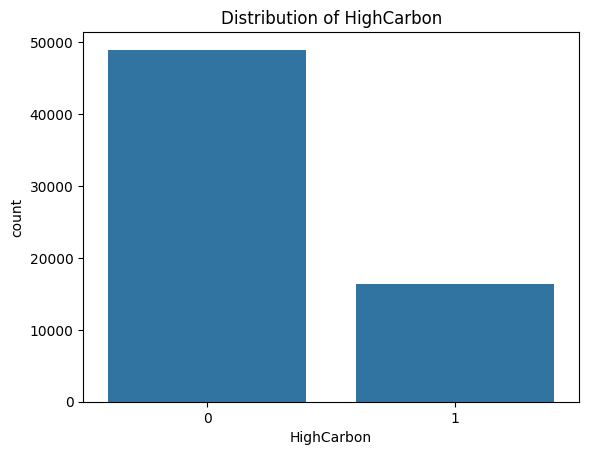

In [9]:
sns.countplot(x="HighCarbon", data=train)
plt.title("Distribution of HighCarbon")
plt.show()

In [10]:
test.head()

,TripID,DepartureLocationCountry,DepartureLocationCity,ArrivalLocationCountry,ArrivalLocationCity,ShippingType,ShippingTypeDescription,Purpose,OutOfPolicy,EntitiyCode,BusinessUnit,HotelNights,NetCosts
0,2,BR,SÃ£o Paulo,ZA,Johannesburg,12,Business Class Flight,Customer Visit,Yes,8000,Sales,6,2400
1,4,CN,Beijing,GB,London,10,Economy Flight,Internal Business Trip,No,8000,Customer Support,3,3150
2,5,AU,Sydney,US,Los Angeles,10,Economy Flight,Conference/Exhibition,No,8000,Marketing,6,3000
3,14,BR,SÃ£o Paulo,US,Miami,10,Economy Flight,Conference/Exhibition,No,8000,Executive Management,2,1350
4,15,DE,Berlin,ES,Madrid,12,Business Class Flight,Conference/Exhibition,Yes,8000,Marketing,2,2850


In [11]:
test.columns

Index(['TripID', 'DepartureLocationCountry', 'DepartureLocationCity',
       'ArrivalLocationCountry', 'ArrivalLocationCity', 'ShippingType',
       'ShippingTypeDescription', 'Purpose', 'OutOfPolicy', 'EntitiyCode',
       'BusinessUnit', 'HotelNights', 'NetCosts'],
      dtype='object')

In [13]:
# Select only common features
features = [
    "DepartureLocationCountry",
    "DepartureLocationCity",
    "ArrivalLocationCountry",
    "ArrivalLocationCity",
    "ShippingType",
    "ShippingTypeDescription",
    "Purpose",
    "OutOfPolicy",
    "EntitiyCode",
    "BusinessUnit",
    "HotelNights",
    "NetCosts"
]

# Features
X = train[features]

# Target
y = train["HighCarbon"]

# Test data
X_test = test[features]

In [14]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
label_encoders = {}

categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()

    # Fit on combined train + test data
    combined = pd.concat([X[col], X_test[col]], axis=0).astype(str)

    le.fit(combined)

    X[col] = le.transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

    label_encoders[col] = le

In [15]:
X.head()

,DepartureLocationCountry,DepartureLocationCity,ArrivalLocationCountry,ArrivalLocationCity,ShippingType,ShippingTypeDescription,Purpose,OutOfPolicy,EntitiyCode,BusinessUnit,HotelNights,NetCosts
0,2,0,8,17,12,2,1,0,9000,11,1,900
1,7,7,11,14,11,5,1,1,6000,10,2,3600
2,1,9,19,8,10,3,0,0,9000,11,1,450
3,3,1,6,19,12,2,1,0,10000,3,1,3450
4,1,9,19,8,10,3,3,0,7000,6,2,1500


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
print(X_train.shape)
print(X_valid.shape)

(52231, 12)
(13058, 12)


In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [19]:
pred = model.predict(X_valid)

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_valid, pred)

print("Accuracy:", accuracy)

Accuracy: 0.9917292081482616


In [21]:
from sklearn.metrics import roc_auc_score

pred_prob = model.predict_proba(X_valid)[:, 1]

roc = roc_auc_score(y_valid, pred_prob)

print("ROC AUC:", roc)

ROC AUC: 0.9979587726270711


In [22]:
test_prob = model.predict_proba(X_test)[:, 1]

In [24]:
submission = pd.read_csv("sample_submission.csv")

submission.head()

,TripID,HighCarbon
0,2,0.0
1,4,0.0
2,5,0.0
3,14,0.0
4,15,0.0


In [25]:
submission["HighCarbon"] = test_prob


In [27]:
submission.to_csv("submission.csv", index=False)

print("Submission file created successfully!")

Submission file created successfully!


In [28]:
submission.head()

,TripID,HighCarbon
0,2,1.0000
1,4,0.0000
2,5,0.9675
3,14,0.0000
4,15,0.0000


In [29]:
# Create a DataFrame of feature importances
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,ArrivalLocationCountry,0.240231
3,ArrivalLocationCity,0.210938
0,DepartureLocationCountry,0.135272
4,ShippingType,0.128378
5,ShippingTypeDescription,0.122260
1,DepartureLocationCity,0.081266
10,HotelNights,0.033270
7,OutOfPolicy,0.015701
11,NetCosts,0.014175
9,BusinessUnit,0.008282


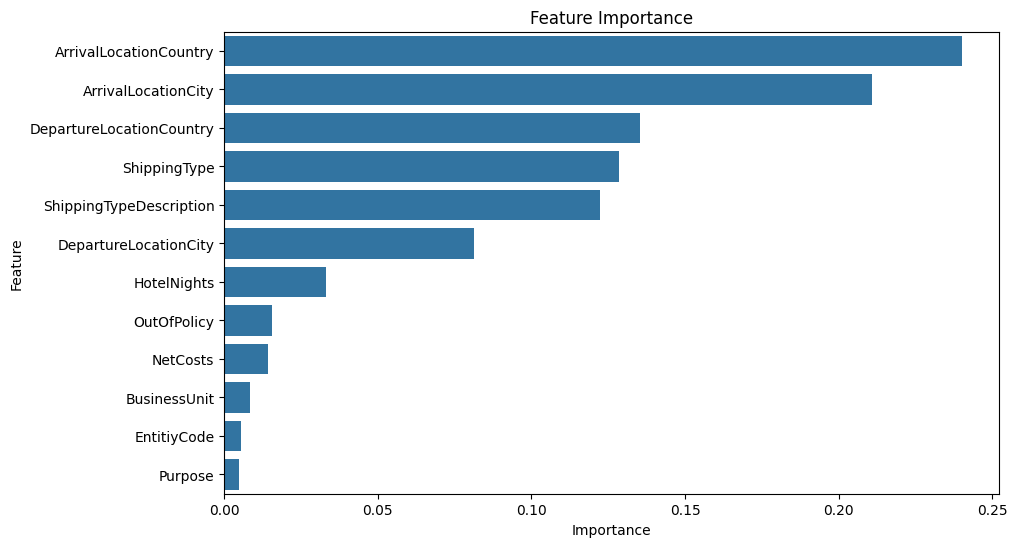

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

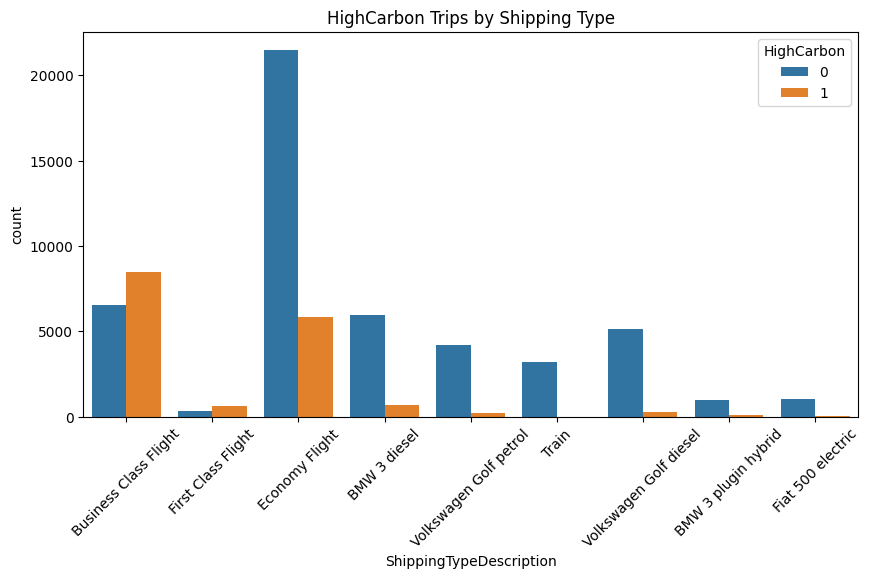

In [31]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=train,
    x="ShippingTypeDescription",
    hue="HighCarbon"
)

plt.xticks(rotation=45)
plt.title("HighCarbon Trips by Shipping Type")
plt.show()

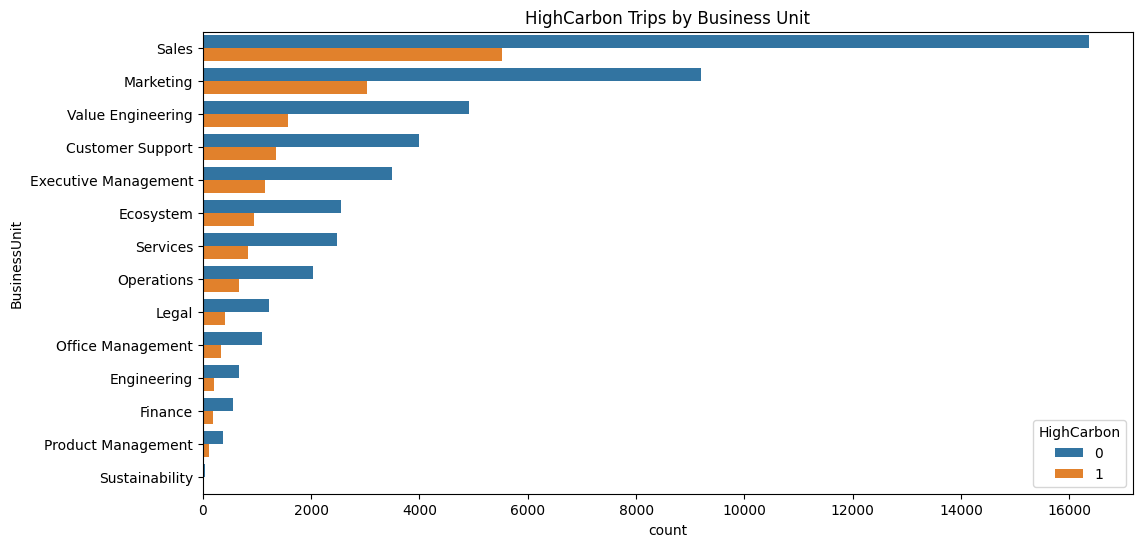

In [32]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=train,
    y="BusinessUnit",
    hue="HighCarbon",
    order=train["BusinessUnit"].value_counts().index
)

plt.title("HighCarbon Trips by Business Unit")
plt.show()

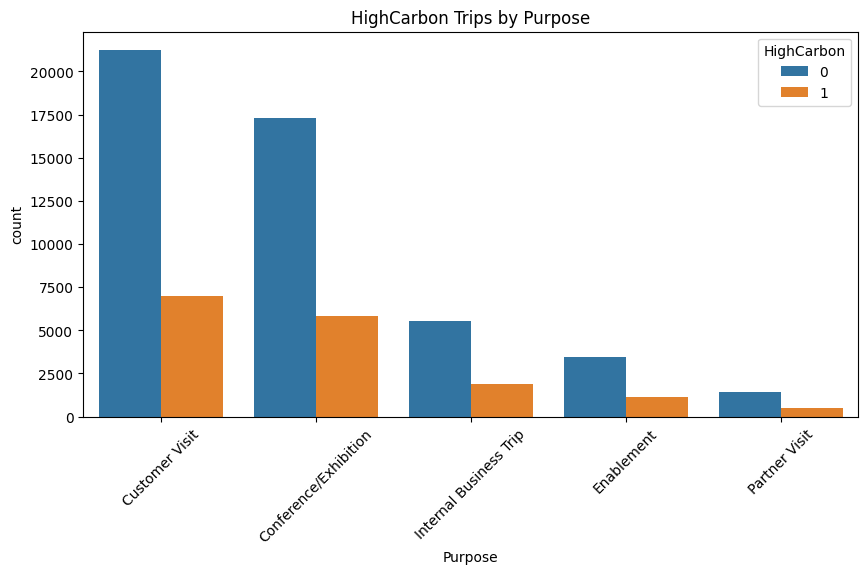

In [33]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=train,
    x="Purpose",
    hue="HighCarbon"
)

plt.xticks(rotation=45)
plt.title("HighCarbon Trips by Purpose")
plt.show()